# Analiza rezultatov z IMO
V tem zvezku analiziramo rezultate Mednarodne matematične olimpijade, podatki so shranjeni v štirih csv datotekah:
- "imo.csv" - podatki o rezultatih tekmovalcev na IMO
- "memo.csv" - podatki o tekmovalcih vsake države na MEMO
- "egmo.csv" - podatki o tekmovalcih vsake države na EGMO
- "jbmo.csv" - podatki o tekmovalcih vsake države na JBMO

V zvezku pogledamo:

1. najboljše države in tekmovalce
2. zmagovalne države
3. rezultate gostiteljev
4. število tekmovalcev in držav
5. leto pridružitve držav
6. uvrstitve Slovenije
7. razlike v težavnosti nalog
8. težavnost nalog čez leta
9. število ponavljajočih se tekmovalcev
10. število podeljenih medalj
11. MEMO tekmovalce na IMO
12. primerjavo z ostalimi tekmovanji

Najprej uvozimo potrebne knjižnice in csv datoteko.

In [169]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("csv_datoteke/imo.csv")

### 1. Najboljše države in tekmovalci
Poglejmo si 20 najuspešnejših držav, 20 najuspešnejših tekmovalcev in top 20 najuspešnejših Slovencev v zgodovini IMO.

In [170]:
from IPython.display import HTML, display

pomembnost = ["G", "S", "B", "HM"]
slog = [
    {
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold"), ("padding", "8px")],
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#f0dcc8"),
            ("color", "#281706"),
            ("padding", "8px 12px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("padding", "6px 12px"),
            ("text-align", "center"),
            ("background-color", "#a25c0c"),
        ],
    },
]


def olepsaj(tabela, naslov):
    return (
        tabela.style.set_caption(naslov)
        .format(precision=0)
        .set_table_styles(slog)
        .to_html()
    )


df["Oseba"] = df["Ime"] + " " + df["Priimek"]
slovenci = df[df["Država"] == "Slovenia"]

medalje_osebe = pd.crosstab(df["Oseba"], df["Medalja"])[pomembnost]
medalje_osebe["Udeležbe"] = df.groupby("Oseba").size()
medalje_drzave = pd.crosstab(df["Država"], df["Medalja"])[pomembnost]
medalje_slovenci = pd.crosstab(slovenci["Oseba"], slovenci["Medalja"])[pomembnost]
medalje_slovenci["Udeležbe"] = df.groupby("Oseba").size()

tabela_osebe = medalje_osebe.sort_values(by=pomembnost, ascending=False).head(20)
tabela_drzave = medalje_drzave.sort_values(by=pomembnost, ascending=False).head(20)
tabela_slovenci = medalje_slovenci.sort_values(by=pomembnost, ascending=False).head(20)


html = f"""
<div style="display: flex; gap: 100px;">
    <div>{olepsaj(tabela_drzave, "Top 20 po državah")}</div>
    <div>{olepsaj(tabela_osebe, "Top 20 po osebah")}</div>
    <div>{olepsaj(tabela_slovenci, "Top 20 Slovencev")}</div>
</div>
"""
display(HTML(html))

Medalja,G,S,B,HM
Država,,,,
People's Republic of China,197,37,6,0
United States of America,160,122,31,1
Russian Federation,110,64,12,0
Republic of Korea,102,87,28,8
Hungary,91,178,121,14
Romania,89,164,114,13
Union of Soviet Socialist Republics,77,67,45,2
Vietnam,73,123,87,3
United Kingdom,61,126,136,18


Kot pričakovano so na prvih mestih med državami matematične velesile, na seznamu pa lahko opazimo tudi nekdanjo državo Sovjetsko zvezo, ki je še danes na 7. mestu po uspešnosti, kljub temu da ne obstaja že 35 let. Med Slovenci je najboljši tekmovalec in edini z zlato medaljo Luka Horjak.

### 2. Zmagovalne države
Zdaj želimo ugotoviti, kolikokrat je katera država dosegla prvo mesto na IMO. Pričakujemo, da bodo med državami z največ zmagami države z vrha seznama uspešnosti.

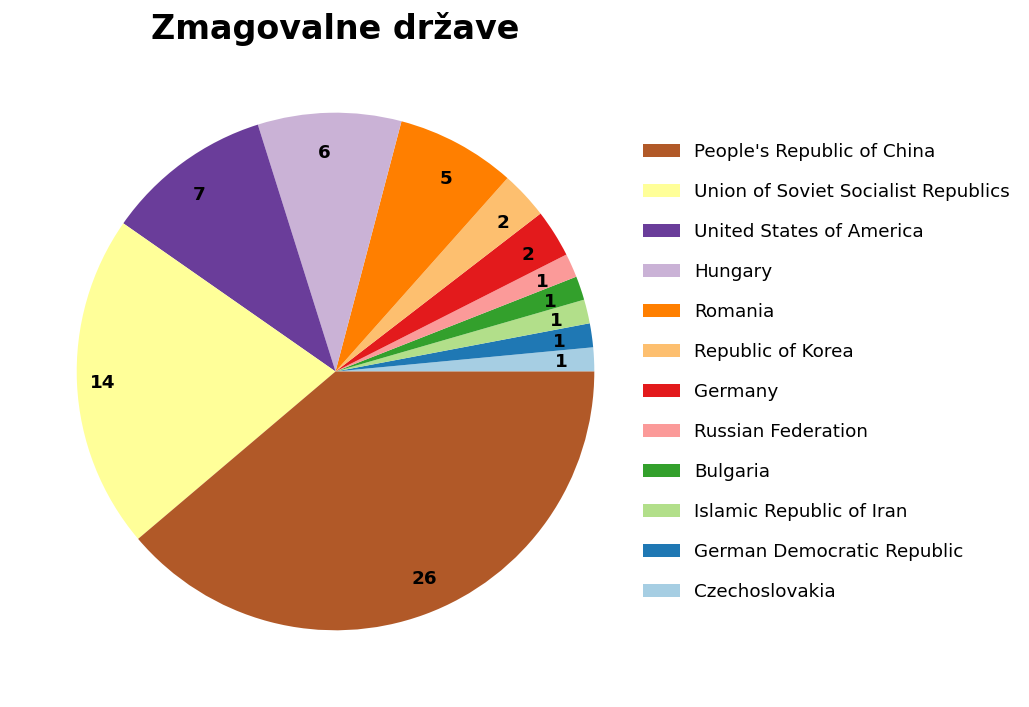

In [171]:
from collections import defaultdict

preimenovanje = {
    "Russian Federation": "Russia/USSR",
    "Union of Soviet Socialist Republics": "Russia/USSR",
    "German Democratic Republic": "Germany",
}

kopija = df.copy()
kopija["Država"] = kopija["Država"]
kopija["Skupno"] = pd.to_numeric(kopija["Skupno"])

tocke_po_letih = kopija.groupby(["Leto", "Država"])["Skupno"].sum().reset_index()

zmage = defaultdict(int)

for leto, podmnozica in tocke_po_letih.groupby("Leto"):
    zmage[podmnozica.loc[podmnozica["Skupno"].idxmax(), "Država"]] += 1


imena, velikosti = zip(*sorted(zmage.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, 6), dpi=120)

kosi, _ = ax.pie(
    velikosti,
    labels=[str(x) for x in velikosti],
    labeldistance=0.85,
    colors=plt.cm.Paired.colors,
    textprops={"fontsize": 11, "color": "black", "weight": "bold"},
)

ax.legend(
    kosi[::-1],
    imena[::-1],
    labelspacing=1.2,
    loc="center left",
    bbox_to_anchor=(0.95, 0.5),
    fontsize=11,
    frameon=False,
)
ax.set_title("Zmagovalne države", fontsize=20, weight="bold")
plt.tight_layout()
plt.show()

Kot vidimo, res tudi po številu zmag vodi Kitajska, zanimivo pa je, da je kljub 67 izvedbam tekmovanja olimpijado zmagalo le 12 različnih držav.

### 3. Rezultati gostiteljice
V tem delu bomo pogledali ali država gostiteljica doma doseže boljše rezultate kot navadno. Pogledamo, v katerem procentu najboljših držav je bila država v vseh svojih letih sodelovanja in leta, ko je bila gostiteljica, ter vzamemo razliko med tema podatkoma. Domnevamo, da olimpijada na domačem terenu tekmovalcem vlije dodatne samozavesti in niso utrujeni od potovanja, zato dosegajo boljše rezultate.

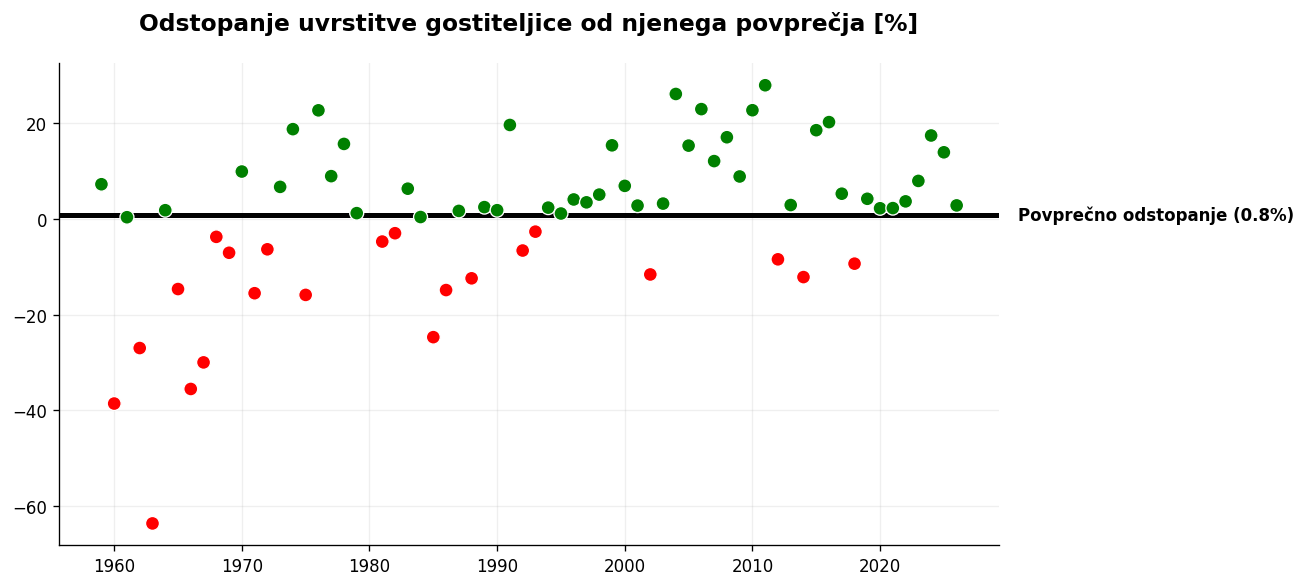

In [172]:
povp_mesto = (
    df.groupby(["Leto", "Država"])["Mesto"].mean().reset_index(name="Povprečno mesto")
)
povp_mesto["Relativna uvrstitev"] = (
    povp_mesto.groupby("Leto")["Povprečno mesto"].rank(method="min", pct=True) * 100
)

povp_relativna = (
    povp_mesto.groupby("Država")["Relativna uvrstitev"]
    .mean()
    .rename("Povprečna relativna uvrstitev")
)

gostitelji = (
    df[["Leto", "Gostiteljica"]]
    .drop_duplicates("Leto")
    .rename(columns={"Gostiteljica": "Država"})
)

g = gostitelji.merge(povp_mesto, on=["Leto", "Država"], how="left").merge(
    povp_relativna, on="Država", how="left"
)
g["Odstopanje"] = g["Povprečna relativna uvrstitev"] - g["Relativna uvrstitev"]
g = g.sort_values("Leto")

povprecje = g["Odstopanje"].mean()
barve = ["green" if v > 0 else "red" if v < 0 else "yellow" for v in g["Odstopanje"]]

plt.figure(figsize=(11, 5), dpi=120)
plt.scatter(
    g["Leto"],
    g["Odstopanje"],
    c=barve,
    s=70,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)
plt.axhline(povprecje, color="black", linewidth=3, zorder=2)
plt.text(
    1.02,
    0.675,
    f"Povprečno odstopanje ({povprecje:.1f}%)",
    transform=plt.gca().transAxes,
    fontsize=10,
    weight="bold",
)

plt.title(
    "Odstopanje uvrstitve gostiteljice od njenega povprečja [%]",
    fontsize=14,
    weight="bold",
    pad=20,
)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo so nekateri tekovalci tekmovali bolje kot ponavadi, nekateri pa slabše. Povprečno odstopanje pa je 0,8 % kar pomeni, da je vpliv domačega terena na IMO zanemarljiv in je naša hipoteza napačna.

### 4. Število tekmovalcev in držav
Ogledali si bomo, kako se je skozi leta spreminjalo število sodelujočih tekmovalcev in držav in odvisnost med tema podatkoma.

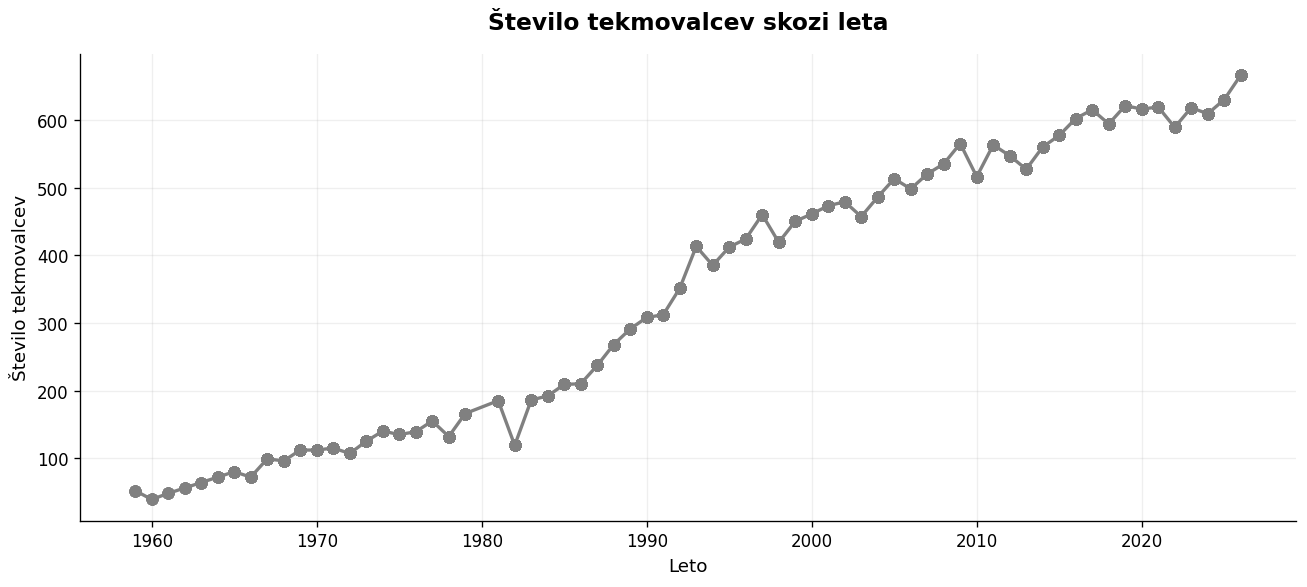

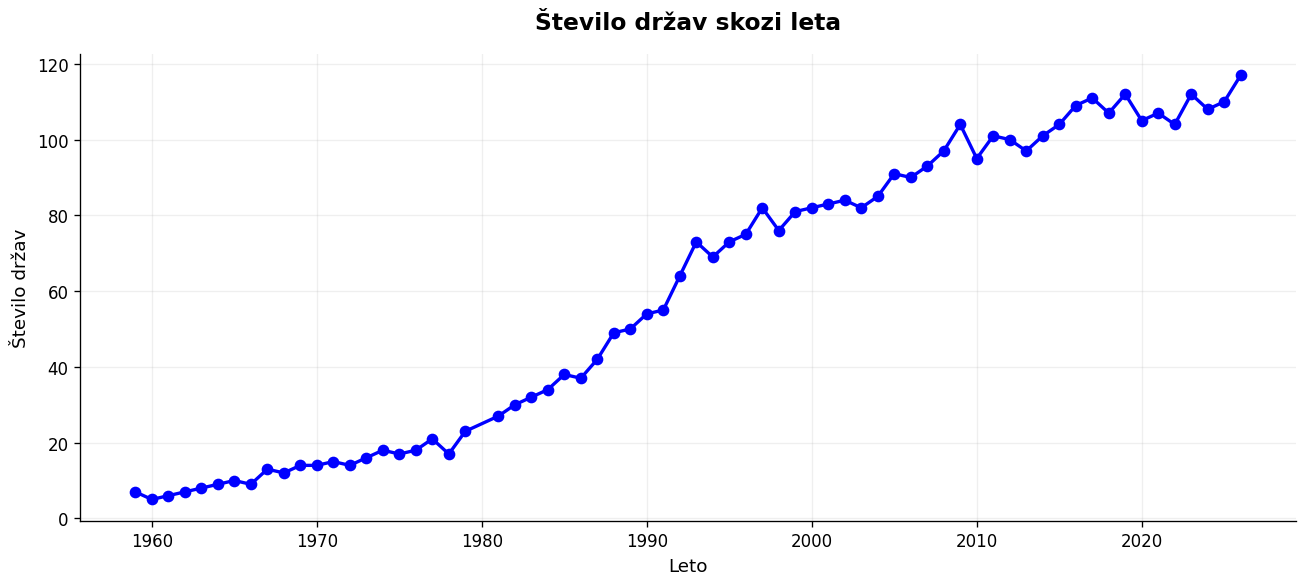

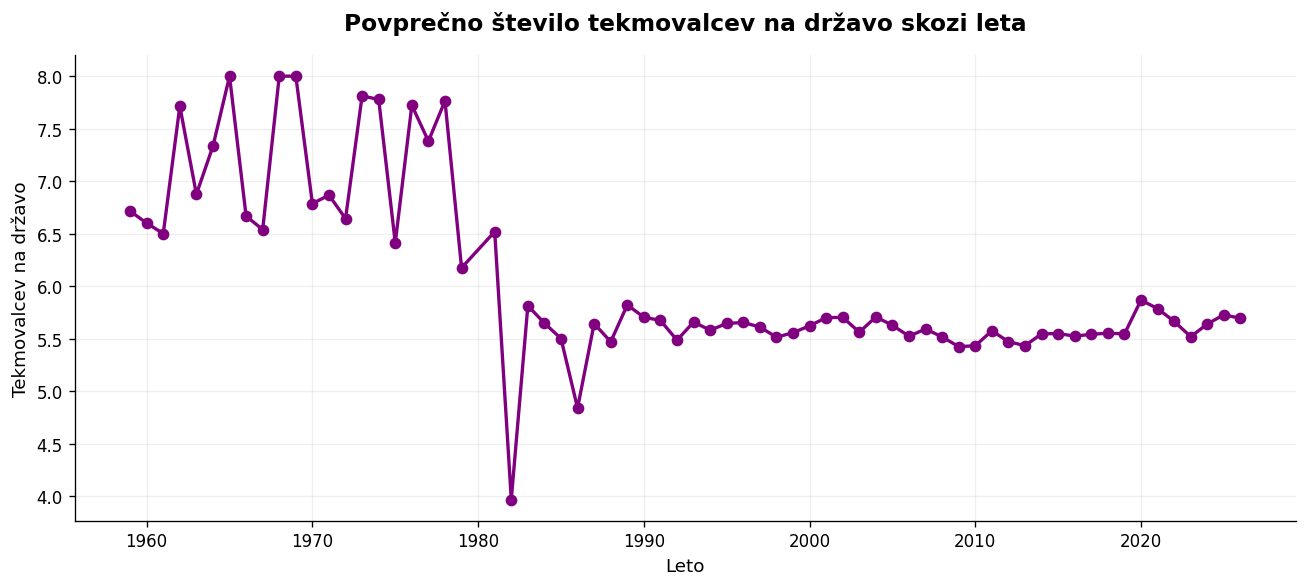

In [173]:
plt.figure(figsize=(11, 5), dpi=120)
plt.plot(df["Leto"], df["Število tekmovalcev"], marker="o", color="gray", linewidth=2)
plt.xlabel("Leto", fontsize=11)
plt.ylabel("Število tekmovalcev", fontsize=11)
plt.title("Število tekmovalcev skozi leta", fontsize=14, weight="bold", pad=15)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

stevilo_drzav = df.groupby("Leto")["Država"].nunique().reset_index(name="Število držav")

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(
    stevilo_drzav["Leto"],
    stevilo_drzav["Število držav"],
    marker="o",
    color="blue",
    linewidth=2,
)
plt.xlabel("Leto", fontsize=11)
plt.ylabel("Število držav", fontsize=11)
plt.title("Število držav skozi leta", fontsize=14, weight="bold", pad=15)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

povp_tekmovalcev = (
    df.groupby("Leto")
    .apply(lambda skupina: skupina["Oseba"].nunique() / skupina["Država"].nunique())
    .reset_index(name="Gostota tekmovalcev")
)

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(
    povp_tekmovalcev["Leto"],
    povp_tekmovalcev["Gostota tekmovalcev"],
    marker="o",
    color="purple",
    linewidth=2,
)
plt.xlabel("Leto", fontsize=11)
plt.ylabel("Tekmovalcev na državo", fontsize=11)
plt.title(
    "Povprečno število tekmovalcev na državo skozi leta",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo na prvih dveh grafih se IMO-ta vsako leto udeleži več takmovalcev in držav. Na tretjem grafu pa lahko vidimo da organizatorji v prvih letih tekmovanja niso bili prepričani o tem, kakšno naj bi bilo število tekmovalcev na državo, najprej je bilo 8, leta 1982 so znižali na 4, danes pa je že kar ustaljeno 6 tekmovalcev na državo. A povprečje je vseeno pod 6, saj nekatere države pošljejo manjše število tekmovalcev.

### 5. Prvo leto sodelovanja
Pogledali bomo katerega leta so se IMO pridružile države, ki so bile na olimpijadi leta 2026.

In [174]:
prvic = df.groupby("Država")["Leto"].min().reset_index(name="Prva udeležba")

drzave_2026 = set(df[df["Leto"] == 2026]["Država"])
prvic = prvic[prvic["Država"].isin(drzave_2026)]

skupine = sorted(prvic.groupby("Prva udeležba"))

sredina = (len(skupine) + 1) // 2
levo = skupine[:sredina]
desno = skupine[sredina:]

vrstice = ""

for i in range(max(len(levo), len(desno))):
    leva = ""
    desna = ""

    if i < len(levo):
        leto, skupina = levo[i]
        drzave = skupina["Država"]
        leva = f"""
        <div class="vrstica">
            <span class="leto">{leto}</span>
            <span>{", ".join(drzave)}</span>
        </div>
        """

    if i < len(desno):
        leto, skupina = desno[i]
        drzave = sorted(skupina["Država"])
        desna = f"""
        <div class="vrstica">
            <span class="leto">{leto}</span>
            <span>{", ".join(drzave)}</span>
        </div>
        """

    vrstice += f"""
    <div class="vrstica-container">
        <div>{leva}</div>
        <div>{desna}</div>
    </div>
    """

html = f"""
<style>
.naslov {{
    font-size: 26px;
    font-weight: bold;
    margin-bottom: 20px;
}}

.vrstica-container {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    column-gap: 60px;
}}

.vrstica {{
    display: flex;
    align-items: baseline;
    gap: 15px;
    font-size: 17px;
    line-height: 1.7;
}}

.leto {{
    font-weight: bold;
    min-width: 45px;
}}
</style>

<div class="naslov">
    Prva udeležba držav na IMO
</div>

{vrstice}
"""

display(HTML(html))

Vidimo lahko, da se Bolgarija, Madžarska, Poljska in Romunija tekmovanja udeležujejo že od samega začetka leta 1959, Slovenija se mu je pridržila leta 1993, zadnji pa sta se leta 2026 pridružili Libija in Senegal.

### 6. Uspešnost Slovenije
Zanima nas ralativna uvrstitev slovenske ekipe skozi leta njenega sodelovanja.

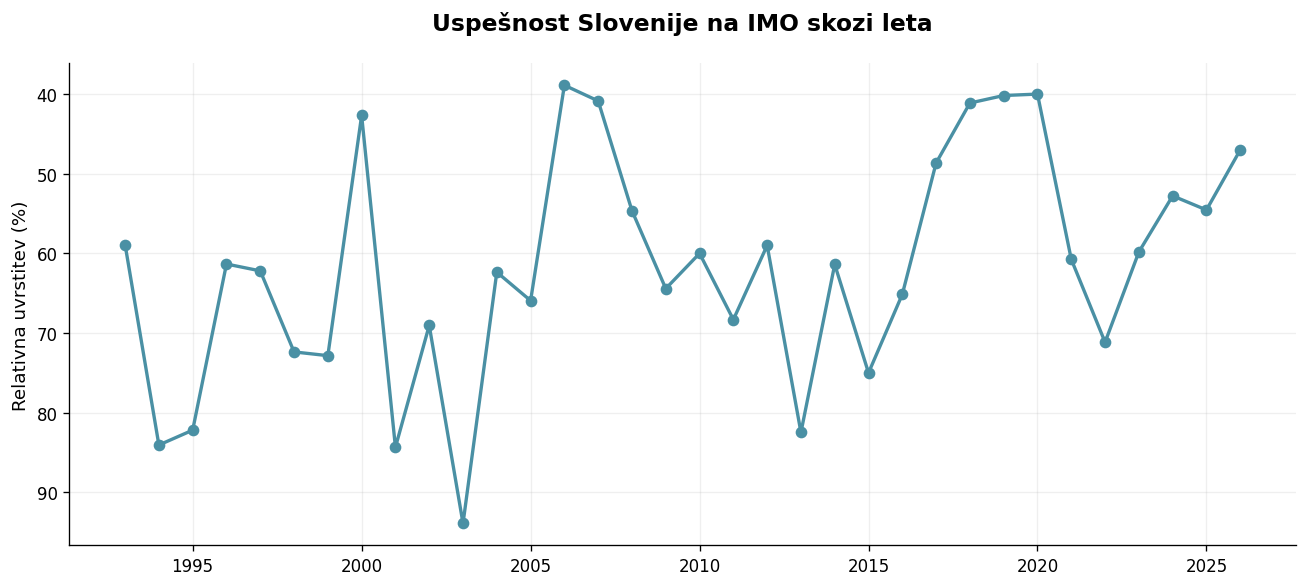

In [175]:
slovenija = povp_mesto[povp_mesto["Država"] == "Slovenia"].sort_values("Leto")

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(
    slovenija["Leto"],
    slovenija["Relativna uvrstitev"],
    marker="o",
    color="#4a90a4",
    linewidth=2,
)
plt.gca().invert_yaxis()
plt.ylabel("Relativna uvrstitev (%)", fontsize=11)
plt.title("Uspešnost Slovenije na IMO skozi leta", fontsize=14, weight="bold", pad=20)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo je Slovenija večino časa med 60 in 70 odstotkov najboljših držav. Najmanj uspešna je bila leta 2003, najuspešnejša pa leta 2006 ko je bila gostiteljica.

### 7. Težavnost nalog
Pogledali bomo odvisnost uvrstitve tekmovalcev od števila točk na posamezni nalogi od leta 2000 naprej. Seveda ob večjem številu točk pričakujemo višjo uvrstitev in zato pozitivno korelacijo.

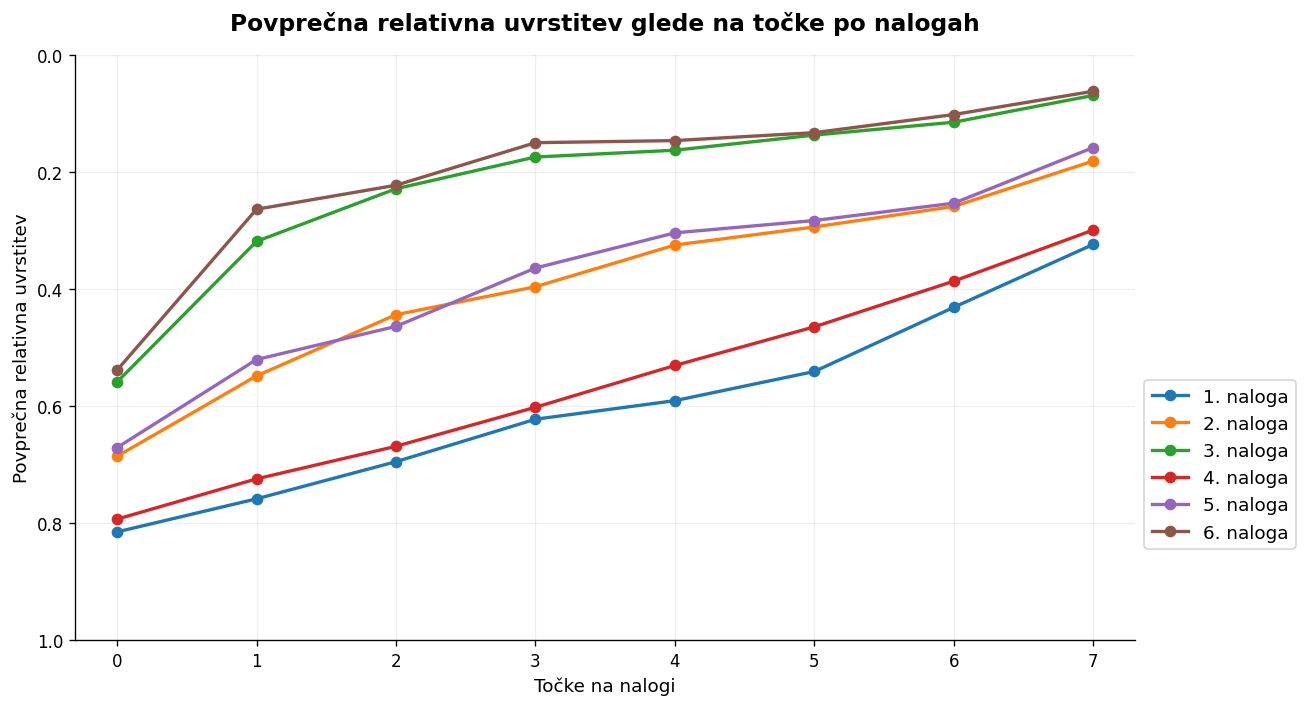

In [176]:
tezavnost = df.copy()
tezavnost = tezavnost[tezavnost["Leto"] >= 2000]
tezavnost["Točke"] = tezavnost["Točke"].apply(eval)

stevilo_tekmovalcev = tezavnost.groupby("Leto")["Mesto"].transform("count")
tezavnost["Relativna uvrstitev"] = tezavnost["Mesto"] / stevilo_tekmovalcev

tocke = pd.DataFrame(
    tezavnost["Točke"].tolist(),
    columns=[f"{i + 1}. naloga" for i in range(6)],
    index=tezavnost.index,
)

zdruzeno = pd.concat([tezavnost[["Relativna uvrstitev"]], tocke], axis=1)

barve = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

for i in range(6):
    stolpec = f"{i + 1}. naloga"
    zdruzeno[stolpec] = pd.to_numeric(zdruzeno[stolpec], errors="coerce")

    povprecja = zdruzeno.groupby(stolpec)["Relativna uvrstitev"].mean().reset_index()

    ax.plot(
        povprecja[stolpec],
        povprecja["Relativna uvrstitev"],
        marker="o",
        color=barve[i],
        label=f"{i + 1}. naloga",
        linewidth=2,
    )

ax.invert_yaxis()
ax.set_ylim(1, 0)
ax.set_xlim(-0.3, 7.3)
ax.set_xlabel("Točke na nalogi", fontsize=11)
ax.set_ylabel("Povprečna relativna uvrstitev", fontsize=11)
ax.set_title(
    "Povprečna relativna uvrstitev glede na točke po nalogah",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.legend(fontsize=11, frameon=True, loc="center left", bbox_to_anchor=(1.0, 0.3))
ax.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo se s številom točk res viša povprečna uvrstitev za vsako izmed nalog. Prav tako vidimo, da so naloge vertikalno razporejene, kar nam pove o njihovi težavnosti. 1. in 4. naloga sta najlažji, sledita jima 2. in 5. naloga, najtežji pa sta 3. in 6. naloga, kar je v skladu z znanimi dejstvi o težavnosti nalog na IMO.

### 8. Težavnost nalog po letih
Kot naslednje si je smiselno ogledati razlike v težavnosti nalog od leta 2000 naprej.

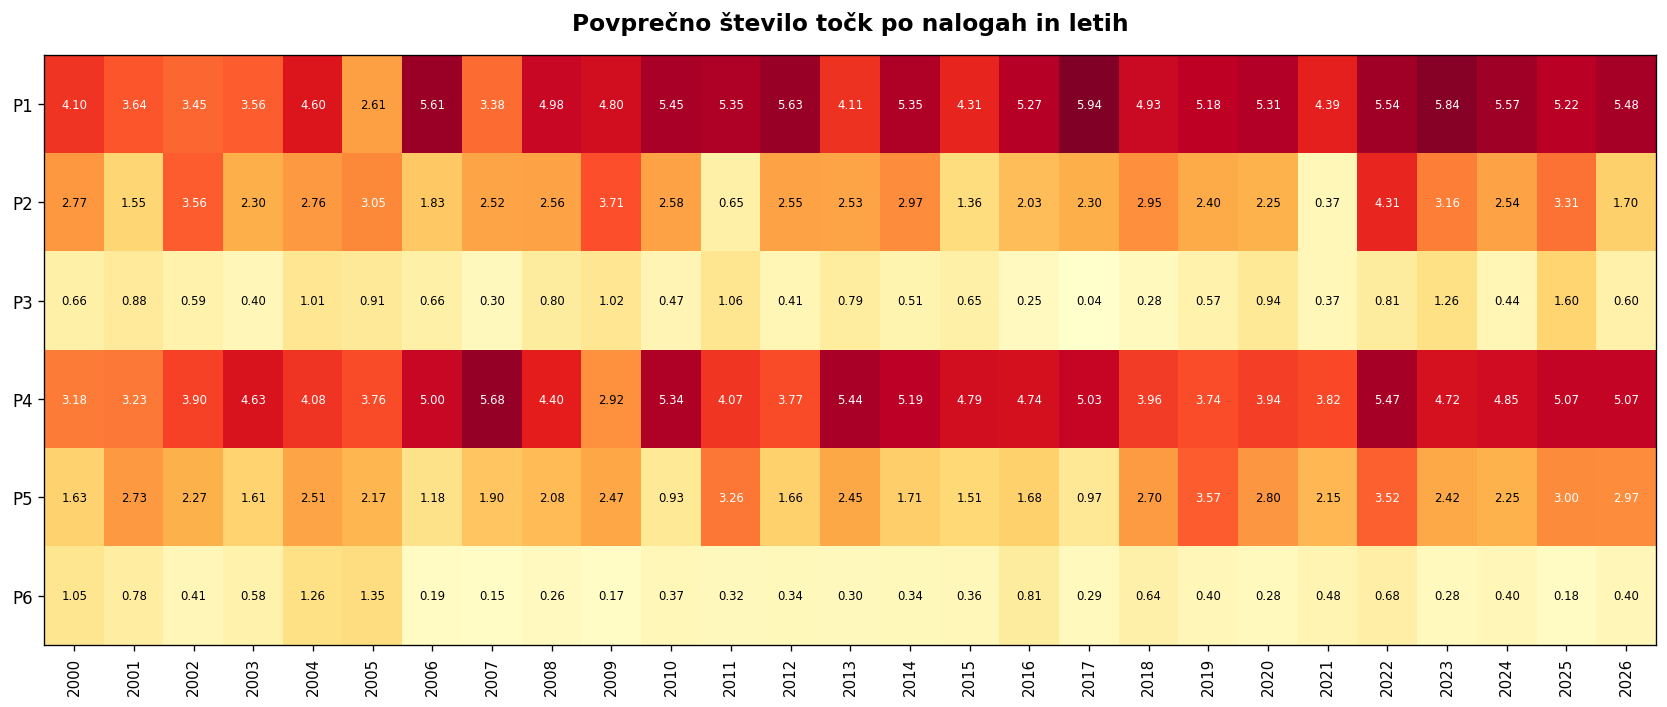

In [182]:
heatmap = df[df["Leto"] >= 2000].copy()
heatmap["Točke"] = heatmap["Točke"].apply(eval)
heatmap = heatmap[heatmap["Točke"].apply(lambda t: len(t) == 6 and "None" not in t)]

tocke = pd.DataFrame(
    heatmap["Točke"].tolist(),
    columns=[f"P{i + 1}" for i in range(6)],
    index=heatmap.index,
).apply(pd.to_numeric, errors="coerce")

tocke["Leto"] = heatmap["Leto"]

povprecja = tocke.groupby("Leto").mean().T

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
im = ax.imshow(povprecja.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(povprecja.columns)))
ax.set_xticklabels(povprecja.columns, fontsize=9, rotation=90)
ax.set_yticks(range(6))
ax.set_yticklabels(povprecja.index, fontsize=10)

ax.set_title(
    "Povprečno število točk po nalogah in letih", fontsize=14, weight="bold", pad=15
)

for i in range(6):
    for j in range(len(povprecja.columns)):
        vrednost = povprecja.values[i, j]
        ax.text(
            j,
            i,
            f"{vrednost:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if vrednost > povprecja.values.max() * 0.5 else "black",
        )

plt.tight_layout()
plt.show()

Najslabše reševana P1 je bila leta 2005, P2 leta 2021, P3 leta 2017, P4 leta 2009, P5 leta 2010, P6 pa leta 2007. Izmed vseh nalog v zadnjih 20 letih pa je bila najslasše reševana 2017 P3.

### 9. Delež enakih tekmovalcev
V tem delu si bomo za vsako od let ogledali, kolikšen delež tekmovalcev je enak kot na prejšnji olimpijadi.

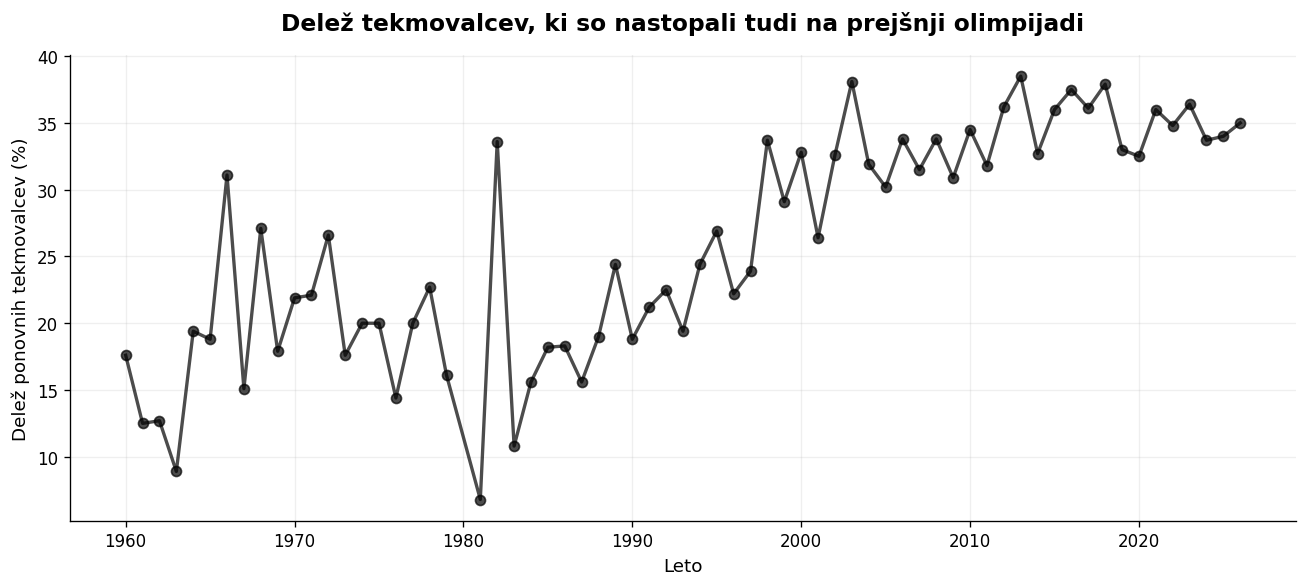

In [183]:
leta_urejeno = sorted(df["Leto"].unique())

delezi = []

for i in range(1, len(leta_urejeno)):
    leto = leta_urejeno[i]
    prejsnje_leto = leta_urejeno[i - 1]

    tekmovalci_letos = set(df[df["Leto"] == leto]["Oseba"])
    tekmovalci_prej = set(df[df["Leto"] == prejsnje_leto]["Oseba"])

    ponovni = tekmovalci_letos & tekmovalci_prej
    delez = len(ponovni) / len(tekmovalci_letos) * 100

    delezi.append({"Leto": leto, "Delež": round(delez, 1)})

ponovitve = pd.DataFrame(delezi)

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(
    ponovitve["Leto"],
    ponovitve["Delež"],
    marker="o",
    color="black",
    linewidth=2,
    alpha=0.7,
)
plt.xlabel("Leto", fontsize=11)
plt.ylabel("Delež ponovnih tekmovalcev (%)", fontsize=11)
plt.title(
    "Delež tekmovalcev, ki so nastopali tudi na prejšnji olimpijadi",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.grid(True, alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo je v začetnih letih letih ta delež kar nihal, verjetno zaradi nefiksnega števila tekmovalcev, zadnja leta pa se giblje okoli 35 %. Najnižji je bil leta 1981, verjetno zaradi tega, ker prejšnje leto olimpijada ni bila izvedena.

### 10. Medalje
Ogledali si bomo, kolikšen delež tekmovalcev dobi zlato, srebno in bronasto medaljo ter pohvalo od leta od leta 1988, ko so prvič začeli podeljevati pohvalo za tekmovace, ki ne dobijo nobene od medalj a dosežejo vse točke na vsaj eni od nalog.

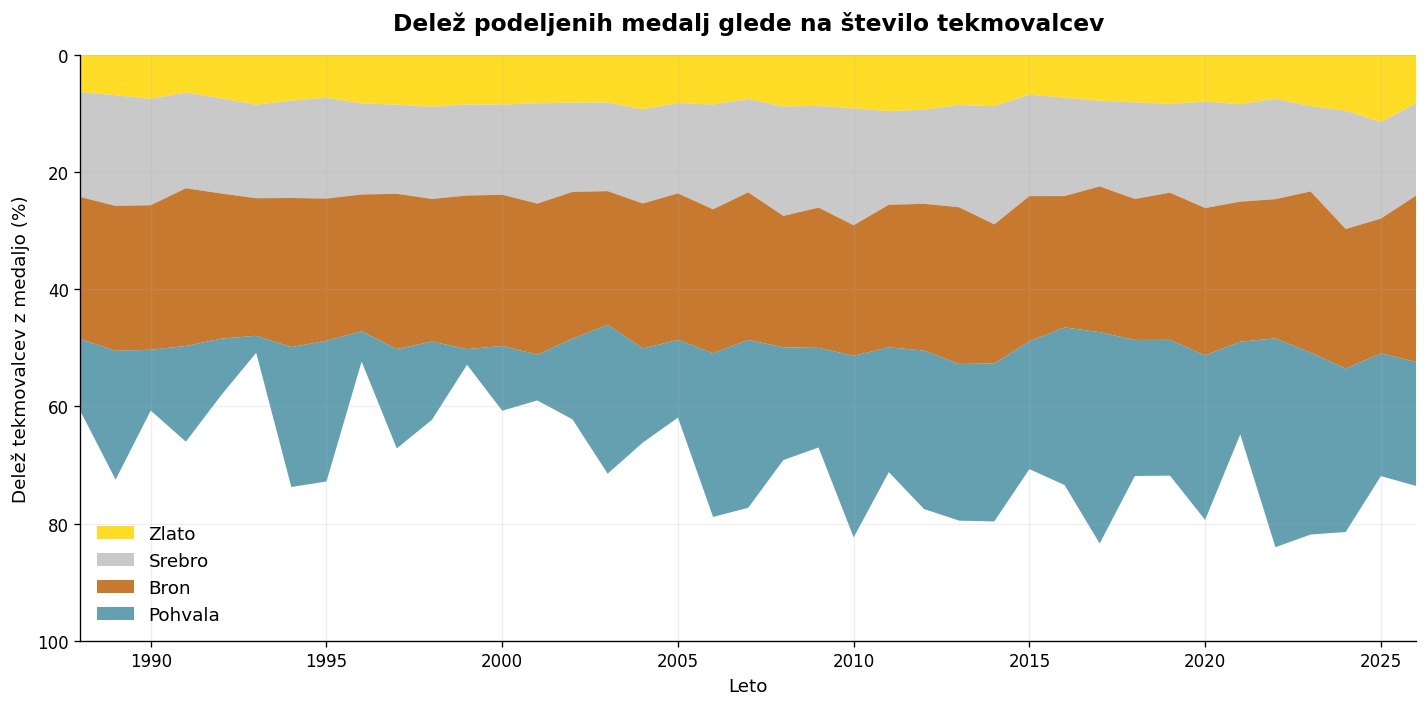

In [184]:
medalje = (
    df[df["Leto"] >= 1988].groupby(["Leto", "Medalja"]).size().unstack(fill_value=0)
)
medalje = medalje[["G", "S", "B", "HM"]]

stevilo_tekmovalcev_po_letih = df[df["Leto"] >= 1988].groupby("Leto")["Oseba"].nunique()
delez = medalje.div(stevilo_tekmovalcev_po_letih, axis=0) * 100

barve = {"G": "gold", "S": "silver", "B": "#BE620C", "HM": "#4a90a4"}

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.stackplot(
    delez.index,
    [delez[m] for m in ["G", "S", "B", "HM"]],
    labels=["Zlato", "Srebro", "Bron", "Pohvala"],
    colors=[barve[m] for m in ["G", "S", "B", "HM"]],
    alpha=0.85,
)

ax.invert_yaxis()
ax.set_ylim(100, 0)
ax.set_xlim(1988, 2026)
ax.set_xlabel("Leto", fontsize=11)
ax.set_ylabel("Delež tekmovalcev z medaljo (%)", fontsize=11)
ax.set_title(
    "Delež podeljenih medalj glede na število tekmovalcev",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.legend(loc="lower left", fontsize=11, frameon=False)
ax.grid(True, alpha=0.2)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Kot vidimo, se delež prejemnikom medalj skozi leta ne pretirano spreminja. Zlato medaljo dobi najboljših 8 %, srebro naslednjih 16 %, bron pa naslednjih 25 %. Tako medalje dobi približno polovica udeležencev.

### 11. MEMO primerjava (po državah)
Iz csv datoteke uvozimo še podatke o predstavnikih vsake države na Srednjeevropski matematični olimpijadi (MEMO). Zanima nas, kolikšnemu deležu MEMO tekmovalcev iz vsake države se je uspelo uvrstiti tudi na IMO.

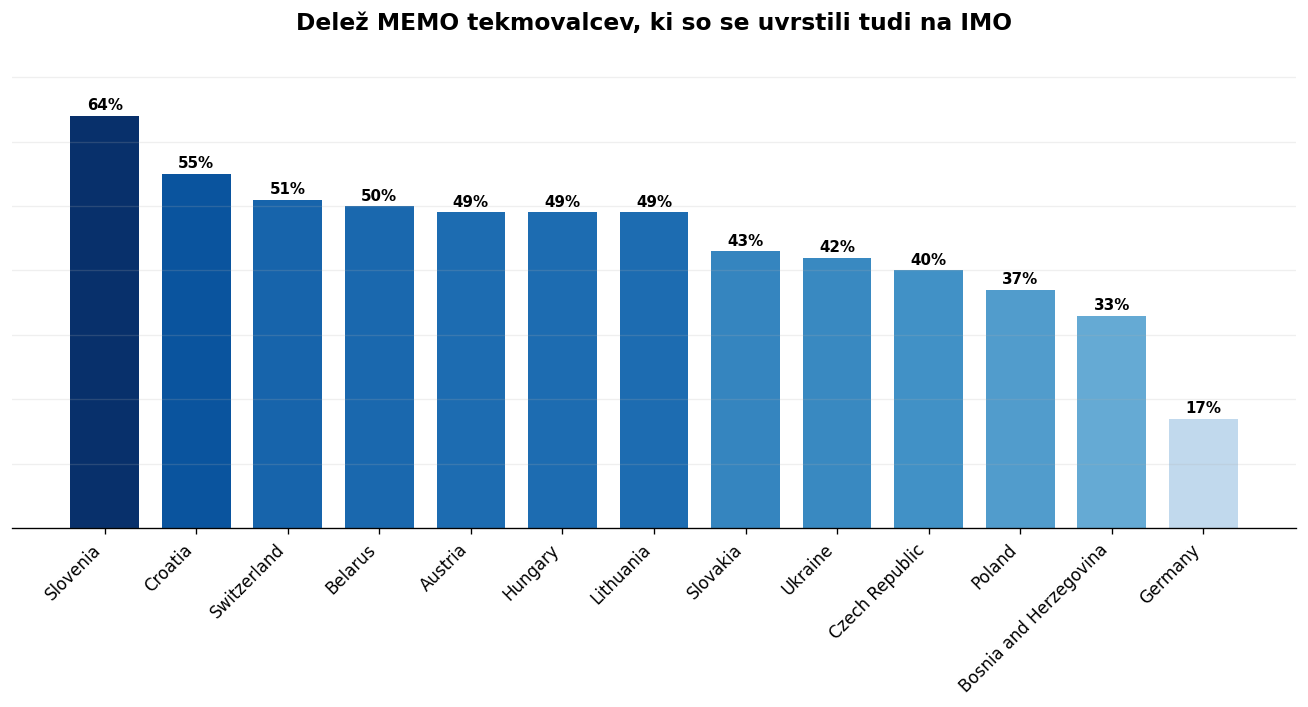

In [185]:
df_memo = pd.read_csv("csv_datoteke/memo.csv")
df_memo["Država"] = df_memo["Država"].replace({"Czechia": "Czech Republic"})

memo = df_memo.groupby("Država")["Tekmovalec"].apply(set)
imo = df.groupby("Država")["Oseba"].apply(set)

primerjava = (
    pd.DataFrame(
        {
            "Država": memo.index,
            "Delež": [
                round(len(memo[d] & imo.get(d, set())) / len(memo[d]) * 100, 0)
                for d in memo.index
            ],
        }
    )
    .sort_values("Delež", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

barve = plt.cm.Blues(primerjava["Delež"] / primerjava["Delež"].max())
stolpci = ax.bar(primerjava["Država"], primerjava["Delež"], width=0.75, color=barve)

for stolpec, vrednost in zip(stolpci, primerjava["Delež"]):
    ax.text(
        stolpec.get_x() + stolpec.get_width() / 2,
        vrednost + 1,
        f"{vrednost:.0f}%",
        ha="center",
        fontsize=9,
        weight="bold",
    )

ax.set_title(
    "Delež MEMO tekmovalcev, ki so se uvrstili tudi na IMO",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xticks(range(len(primerjava)))
ax.set_xticklabels(primerjava["Država"], rotation=45, ha="right")
ax.tick_params(axis="y", left=False, labelleft=False)
ax.set_ylim(0, primerjava["Delež"].max() * 1.15)
ax.grid(axis="y", alpha=0.2)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo je na prvem mestu s 64 % Slovenija, kar ni presenetljivo, saj je v preteklosti Slovenija na MEMO in IMO pošiljala isto ekipo. Na zadnjem mestu pa je Nemčija s 17 %, kar je prav tako pričakovano zaradi njenega velikega števila prebivalstva in večje konkurence.

### 12. Primerjava z ostalimi tekmovanji
Poleg MEMO bomo pogledali še kakšen delež tekmovalcev z EGMO (European girls' mathematical olympiad) in JBMO (Junior Balkan mathematical olympiad) se uvrsti na IMO.

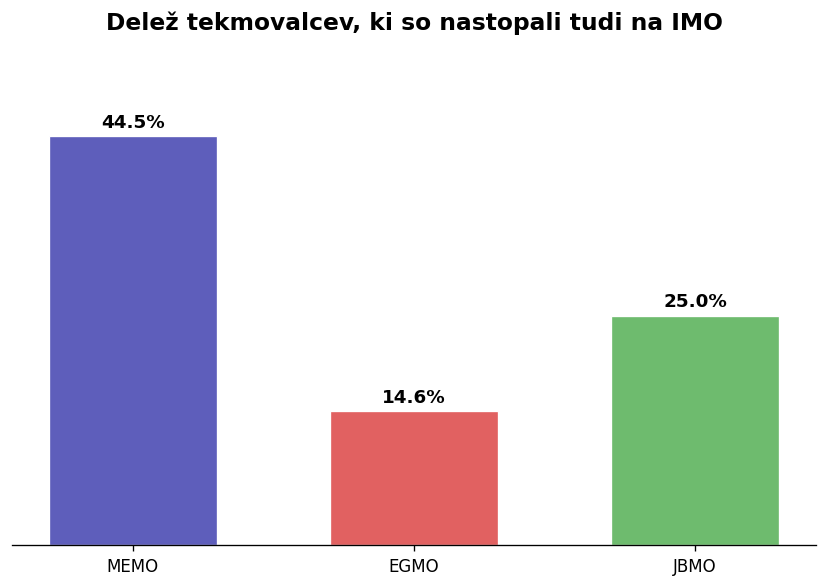

In [186]:
df_egmo = pd.read_csv("csv_datoteke/egmo.csv")
df_jbmo = pd.read_csv("csv_datoteke/jbmo.csv")

memo_tekmovalci = set(df_memo["Tekmovalec"])
imo_tekmovalci = set(df["Oseba"])
egmo_tekmovalci = set(df_egmo["Tekmovalec"])
jbmo_tekmovalci = set(df_jbmo["Tekmovalec"])

memo_delez = round(
    len(memo_tekmovalci & imo_tekmovalci) / len(memo_tekmovalci) * 100, 1
)
egmo_delez = round(
    len(egmo_tekmovalci & imo_tekmovalci) / len(egmo_tekmovalci) * 100, 1
)
jbmo_delez = round(
    len(jbmo_tekmovalci & imo_tekmovalci) / len(jbmo_tekmovalci) * 100, 1
)

x = ["MEMO", "EGMO", "JBMO"]
y = [memo_delez, egmo_delez, jbmo_delez]

plt.figure(figsize=(7, 5), dpi=120)
plt.bar(
    x,
    y,
    color=["#5E5EBB", "#E16161", "#6EBB6E"],
    width=0.6,
    edgecolor="white",
    linewidth=0.8,
)

for i, vrednost in enumerate(y):
    plt.text(i, vrednost + 1, f"{vrednost}%", ha="center", fontsize=11, weight="bold")

plt.title(
    "Delež tekmovalcev, ki so nastopali tudi na IMO", fontsize=14, weight="bold", pad=15
)
plt.ylim(0, max(y) * 1.2)
plt.gca().set_yticks([])
plt.grid(axis="y", alpha=0.2)

for spine in ["top", "right", "left"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Zaključek
V zvezku smo pogledali številna zanimiva dejstva o rezultatih z IMO in prekrivanje z udeleženci ostalih olimpijad, projekt bi lahko smiselno razširili tako, da bi pridobili tudi rezultate iz teh ostalih olimpijad in pogledali, če se isti vzorci kot na IMO pojavljajo tudi drugje.